#### [ CNN Fashion MNIST MODEL ]


In [1]:
## 
import torch                                    ##Tensor 및 기본 함수들 관련 모듈
import torch.nn as nn                           ## 인공신경망 관련 모듈
import torch.nn.functional as F                           ## 인공신경망 관련 모듈
from torchvision.datasets import FashionMNIST  ## 비전관련 내장 데이터셋 모듈
from torch.utils.data import DataLoader         ## pytorch의 데이터셋 관련 모듈

import torchvision.transforms as transfroms     ## 비전관련 이미지 증강 / 변환 관련 모듈
import matplotlib.pyplot as plt                 ## 시각화

In [2]:
## 이미지 관련 준비
IMG_ROOT = '../_image/fashion/'                         ##이미지 데이터 저장 경로


In [3]:
# [2] 데이터 로딩


In [4]:
trainDS = FashionMNIST(root=IMG_ROOT, download=True, train=True, transform=transfroms.ToTensor())

In [5]:
testDS = FashionMNIST(root=IMG_ROOT, download=True, train=False, transform=transfroms.ToTensor())


In [6]:
print(f"type    : {type(testDS)}")

print(f'classes     : {testDS.classes}')
print(f'class_to_idx     : {testDS.class_to_idx}')


type    : <class 'torchvision.datasets.mnist.FashionMNIST'>
classes     : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_to_idx     : {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [7]:
print(f'targets     : {testDS.targets}')
print(f'data     : {testDS.data.shape}')

targets     : tensor([9, 2, 1,  ..., 8, 1, 5])
data     : torch.Size([10000, 28, 28])


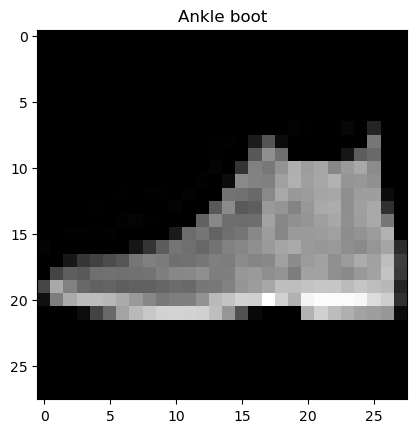

In [8]:
idx_to_classes = {v:k for k, v in testDS.class_to_idx.items()}

plt.imshow(testDS.data[0], cmap='gray')
plt.title(idx_to_classes[testDS.targets[0].item()])
plt.show()


In [9]:
print(f"Raw Image Data: {testDS.data[0].min()}, {testDS.data[0].max()}")

Raw Image Data: 0, 255


[3] 모델 설계 <hr>

In [10]:
class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN, self).__init__()
        self.in_layer = nn.Flatten()       
        self.fc1 = nn.Linear(in_features=784, out_features=512)
        self.drop = nn.Dropout(0.25)  # Dropout 적용
        self.fc2 = nn.Linear(in_features=512, out_features=256)
        self.drop2 = nn.Dropout(0.25)  # Dropout 추가
        self.fc3 = nn.Linear(in_features=256, out_features=128)
        self.fc4 = nn.Linear(in_features=128, out_features=10)
        
    def forward(self, input_data):
        out = self.in_layer(input_data)  # Flatten 적용
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.drop2(out)
        out = F.relu(self.fc3(out))
        out = self.fc4(out)
        return out

# 모델 확인
model = FashionDNN()
print(model)


FashionDNN(
  (in_layer): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
from torchinfo import summary

In [12]:
m1 = FashionDNN()
summary(m1, input_size=(100,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
FashionDNN                               [100, 10]                 --
├─Flatten: 1-1                           [100, 784]                --
├─Linear: 1-2                            [100, 512]                401,920
├─Dropout: 1-3                           [100, 512]                --
├─Linear: 1-4                            [100, 256]                131,328
├─Dropout: 1-5                           [100, 256]                --
├─Linear: 1-6                            [100, 128]                32,896
├─Linear: 1-7                            [100, 10]                 1,290
Total params: 567,434
Trainable params: 567,434
Non-trainable params: 0
Total mult-adds (M): 56.74
Input size (MB): 0.31
Forward/backward pass size (MB): 0.72
Params size (MB): 2.27
Estimated Total Size (MB): 3.31

In [13]:
testImg = trainDS.data[0:2].float()
pre = m1(testImg).argmax()
pre, trainDS.targets[0:2]

(tensor(15), tensor([9, 0]))

In [14]:
# for img, target in trainDS:
#     print(img.shape, target)

In [ ]:
# self.con_layer1 = nn.Conv2d(1,1, 3, padding=1)
# self.pool_layer1 = nn.MaxPool2d(2)
# self.con_layer2 = nn.Conv2d

In [45]:
## 모델층 구성
## 특징 추출 입력 이미지 주요 특징 추출한 특징맵 feature Map
#   합성곱층   이미지채널/커널수     출력채널/커널수     커널사이즈    패딩크기      스트라이드
                    #   1                     1                   3, 5      0 (default:0)   1 (default:0)
#     풀링층        커널크기,           스트라이드(겹침방지를 위해 커널크기와 스트라이드는 동일하게 가는게 일반적)
#                       2                   2   
#     플랫층        nn.flatten() 
# #
# #
## 전결합 학습 추출된 FeatureMap으로 학습 진행
##     은닉층    커널수 * 높이 * 너비       출력/퍼셉트론 수 
##                                              30
##      은닉층          30                      15
##      출력층          15                      10

class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        ## 특징맵 추출 부분
        self.con_layer1 = nn.Conv2d(1, 1, 3)        ## 1, 1, 28, 28 ==> (1, 1, 26, 26)
        self.pool_layer1 = nn.MaxPool2d(2,2)        ## 1, 1, 26, 26 ==> (1, 1, 13, 13)
        self.flat_layer = nn.Flatten()              ## (1, 1, 13, 13) ==> (1, 1*13*13)
        
        ## 전결합 학습 부분
        self.fc_layer1 = nn.Linear(169, 30)
        self.h_layer1 = nn.Linear(30, 15)
                
        self.out_layer = nn.Linear( 15 , 10)
        

In [46]:
# class FashionCNN(nn.Module):
#     def __init__(self):
#         super(FashionCNN, self).__init__()
#         self.layer1 = nn.Sequential(
#             nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(kernel_size=2, stride=2)  # (28x28 → 14x14)
#         )
#         self.layer2 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(2)  # (14x14 → 6x6)
#         )
        
#         self.fc1 = nn.Linear(in_features=64 * 6 * 6, out_features=600)
#         self.drop = nn.Dropout(0.25)  # Dropout2d 대신 Dropout 사용
#         self.fc2 = nn.Linear(in_features=600, out_features=120)
#         self.fc3 = nn.Linear(in_features=120, out_features=10)
        
#     def forward(self, x):
#         out = self.layer1(x)
#         out = self.layer2(out)
#         out = out.view(out.size(0), -1)  # Flatten
#         out = F.relu(self.fc1(out))
#         out = self.drop(out)
#         out = F.relu(self.fc2(out))
#         out = self.fc3(out)
#         return out


In [47]:
m1 = FashionCNN()
summary(m1, input_size=(100,1,28,28))

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []

In [42]:
for img, target in testDS:
    print(img.shape, target)
    pre = m1(img.unsqueeze(1))
    print(pre, target)
    break

torch.Size([1, 28, 28]) 9
tensor([[ 0.2221, -0.2435, -0.0838, -0.0780,  0.2431, -0.0886,  0.1357, -0.1609,
         -0.0152,  0.1383]], grad_fn=<AddmmBackward0>) 9


[3] 학습 준비 <hr>

In [16]:
import sys
sys.path.append('../_utils')
from DL_Module import *

In [40]:
check = MyModel((1,28,28), 10, 128, [32, 32, 16])

TypeError: empty(): argument 'size' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got tuple"

In [36]:
check_c = TT_classifier(check, trainDS, testDS)

In [37]:
check_c.cycling()

RuntimeError: only batches of spatial targets supported (3D tensors) but got targets of dimension: 1

In [52]:
## [5-1] 학습 관련 설정들
EPOCHS = 10                                         # 학습용 DS를 처음부터 끝까지 1번 학습하는 것을 에포크
BATCH_SIZE = 100                                    # DS를 학습량 만큼 나눈 사이즈
T_ITERATION = int(trainDS.data.shape[0]/BATCH_SIZE)         # 학습용 DS이 분리된 수 => 1에포크에 W, b 업데이트 횟수
LR = 0.001
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"DEVICE : {DEVICE}, EPOCHS : {EPOCHS}, BATCH_SIZE : {BATCH_SIZE} ITERATION: {T_ITERATION}")
      

DEVICE : cpu, EPOCHS : 10, BATCH_SIZE : 100 ITERATION: 600
